In [2]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.optimize import minimize

from quant_rotor.Hamiltonian_models.Dense.support_ham import H_kinetic, H_potential_combined

from quant_rotor.Hamiltonian_models.Dense.heisenberg_hamiltonian import hamiltonian_dense
from quant_rotor.Hamiltonian_models.Dense.combine_hamiltonian import combine_hamiltonian


from quant_rotor.Hamiltonian_models.Dense.density_matrix import density_matrix_1

from quant_rotor.CCC_iterative_methods.Dense.t_amplitudes_periodic import t_periodic
from quant_rotor.CCC_iterative_methods.Dense.t_amplitudes_guess import t_1_amplitude_guess_ground_state, t_2_amplitude_guess_ground_state, amplitute_energy, intermediate_normalisation

In [3]:
np.set_printoptions(precision=5)
np.set_printoptions(suppress=True)
np.set_printoptions(linewidth=np.inf)
np.set_printoptions(threshold=np.inf)

In [4]:
def index_degenerate(a, decimals=None):
    a = np.asarray(a)
    a_flat = a.ravel()

    key = np.round(a_flat, decimals) if decimals is not None else a_flat

    pairs = []

    vals, counts = np.unique(key, return_counts=True)

    for v in range(vals.shape[0]):
        idx = np.flatnonzero(key == vals[v])
        if idx.size >= 2:
            pairs.extend(combinations(idx, counts[v]))

    return pairs

# Designing Heisenberg hamiltonian.

## Define functions.

In [3]:
def sigma_ham(sites: int, sigma: np.ndarray, i: int) -> np.ndarray:

    states = 2

    K_H = np.zeros((states**sites, states**sites), dtype=complex)

    n_lambda = states ** (i)
    n_mu = states ** (sites - i - 1)

    for p in range(states):
        for p_prime in range(states):

            val = sigma[p, p_prime]

            if val == 0:
                continue

            for Lambda in range(int(n_lambda)):
                for mu in range(int(n_mu)):

                    i = mu + p * n_mu + Lambda * states * n_mu
                    j = mu + p_prime * n_mu + Lambda * states * n_mu

                    K_H[i, j] = val
    return K_H

In [4]:
def sibma_kron(site: int, sigma: np.ndarray, i: int):

    I_f = np.eye(2**(i))
    I_e = np.eye(2**(site - i - 1))

    single_term = np.kron(I_f, np.kron(sigma, I_e))

    return single_term

In [5]:
def heis_ham_kron(site: int, J_x: int, J_y: int, J_z: int, h_x: int, h_y: int, h_z: int, g):

    sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
    sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
    sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)

    single_term = np.zeros((2**site, 2**site), dtype=complex)
    double_term = np.zeros((2**site, 2**site), dtype=complex)

    for i in range(site):

        if h_x != 0:
            single_term += h_x * sibma_kron(site, sigma_x, i)

        if h_y != 0:
            single_term += h_y * sibma_kron(site, sigma_y, i)

        if h_z != 0:
            single_term += h_z * sibma_kron(site, sigma_z, i)

    for i in range(site-1):

        if J_x != 0:
            x_term =  sibma_kron(site, sigma_x, i)
            x_term_int =  sibma_kron(site, sigma_x, i+1)

            double_term += J_x * x_term @ x_term_int

        if J_y != 0:
            y_term =  sibma_kron(site, sigma_y, i)
            y_term_int =  sibma_kron(site, sigma_y, i+1)

            double_term += J_y * y_term @ y_term_int

        if J_z != 0:
            z_term =  sibma_kron(site, sigma_z, i)
            z_term_int =  sibma_kron(site, sigma_z, i+1)

            double_term += J_z * z_term @ z_term_int

    return single_term + double_term*g, single_term, J_x * x_term @ x_term_int

In [6]:
def heis_ham(site: int, J_x: int, J_y: int, J_z: int, h_x: int, h_y: int, h_z: int, g_val: float):

    sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
    sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
    sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)

    single_term = np.zeros((2**site, 2**site), dtype=complex)
    double_term = np.zeros((2**site, 2**site), dtype=complex)
    double_term_X = np.zeros((2**site, 2**site), dtype=complex)
    double_term_Y = np.zeros((2**site, 2**site), dtype=complex)
    double_term_Z = np.zeros((2**site, 2**site), dtype=complex)

    for i in range(site):

        if h_x != 0:
            single_term += h_x * sigma_ham(site, sigma_x, i)

        if h_y != 0:
            single_term += h_y * sigma_ham(site, sigma_y, i)

        if h_z != 0:
            single_term += h_z * sigma_ham(site, sigma_z, i)

    for i in range(site-1):

        if J_x != 0:
            x_term =  sigma_ham(site, sigma_x, i)
            x_term_int =  sigma_ham(site, sigma_x, i+1)

            double_term_X += J_x * x_term @ x_term_int

        if J_y != 0:
            y_term =  sigma_ham(site, sigma_y, i)
            y_term_int =  sigma_ham(site, sigma_y, i+1)

            double_term_Y += J_y * y_term @ y_term_int

        if J_z != 0:
            z_term =  sigma_ham(site, sigma_z, i)
            z_term_int =  sigma_ham(site, sigma_z, i+1)

            double_term_Z += J_z * z_term @ z_term_int

    double_term = double_term_X + double_term_Y + double_term_Z

    return single_term + double_term * g_val, single_term, double_term * g_val

##

In [7]:
state = 2
site = 3

g = 1

In [8]:
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)

i = 3

In [9]:
s = sigma_z

In [10]:
single_term = sigma_ham(site, s, 0)
single_term_int =  sigma_ham(site, s, 1)

single_term_kron = sibma_kron(site, s, 0)
single_term_int_kron = sibma_kron(site, s, 1)

In [11]:
single_term_kron.shape

(8, 8)

In [12]:
double_term = single_term @ single_term_int
double_term_kron = single_term_kron @ single_term_int_kron

In [13]:
print("Single:", np.array_equal(single_term, single_term_kron))
print("Single_int:", np.array_equal(single_term_int, single_term_int_kron))
print("Double:", np.array_equal(double_term, double_term_kron))

Single: True
Single_int: True
Double: True


In [14]:
H_heis_kron = heis_ham_kron(site, 1, 1, 1, 0, 0, 1, 1)

In [15]:
H_heis_kron

(array([[ 5.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  1.+0.j,  2.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  2.+0.j, -1.+0.j,  0.+0.j,  2.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j,  2.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  2.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  0.+0.j,  2.+0.j,  0.+0.j, -3.+0.j,  2.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  2.+0.j, -1.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j]]),
 array([[ 3.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0

In [16]:
H_heis = heis_ham(site, 1, 1, 1, 0, 0, 1, 1)

In [17]:
H_heis

(array([[ 5.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  1.+0.j,  2.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  2.+0.j, -1.+0.j,  0.+0.j,  2.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j,  2.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  2.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  0.+0.j,  2.+0.j,  0.+0.j, -3.+0.j,  2.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  2.+0.j, -1.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j]]),
 array([[ 3.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0

In [18]:
periodic = False

In [19]:
O_1_x = H_kinetic(2, site, sigma_x)
O_1_y = H_kinetic(2, site, sigma_y)
O_1_z = H_kinetic(2, site, sigma_z)

sigma_x_2 = np.kron(sigma_x, sigma_x)
sigma_y_2 = np.kron(sigma_y, sigma_y)
sigma_z_2 = np.kron(sigma_z, sigma_z)

O_2_x = H_potential_combined(2, site, sigma_x_2, periodic)
O_2_y = H_potential_combined(2, site, sigma_y_2, periodic)
O_2_z = H_potential_combined(2, site, sigma_z_2, periodic)

In [20]:
O_2_x.shape

(8, 8)

In [21]:
O_2_y.imag

array([[0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.]])

In [22]:
O_2_z.imag

array([[0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.]])

In [23]:
H_old = O_2_x + O_2_y + O_2_z + O_1_z

In [24]:
np.array_equal(H_heis_kron, H_old)

False

In [25]:
H_old

array([[ 5.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  1.+0.j,  2.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  2.+0.j, -1.+0.j,  0.+0.j,  2.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j,  2.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  2.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  2.+0.j,  0.+0.j, -3.+0.j,  2.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  2.+0.j, -1.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j]])

In [26]:
H_heis_kron

(array([[ 5.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  1.+0.j,  2.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  2.+0.j, -1.+0.j,  0.+0.j,  2.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j,  2.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  2.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  0.+0.j,  2.+0.j,  0.+0.j, -3.+0.j,  2.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  2.+0.j, -1.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j]]),
 array([[ 3.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0

In [27]:
H_heis

(array([[ 5.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  1.+0.j,  2.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  2.+0.j, -1.+0.j,  0.+0.j,  2.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j,  2.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  2.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  0.+0.j,  2.+0.j,  0.+0.j, -3.+0.j,  2.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  2.+0.j, -1.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j]]),
 array([[ 3.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
        [ 0.+0

# Test CCC.

In [28]:
def h_term(K, h_upper, h_lower):
    a_h_shift = [1 if a_check == 1 else 0 for a_check in (h_upper, h_lower)]
    return K[a_h_shift[0]:h_upper + a_h_shift[0], a_h_shift[1]:h_lower + a_h_shift[1]]


In [29]:
def v_term(V, v_upper_1, v_upper_2, v_lower_1, v_lower_2):
    a_v_shift = [
        1 if a_check == 1 else 0
        for a_check in (v_upper_1, v_upper_2, v_lower_1, v_lower_2)
    ]
    return V[
        a_v_shift[0] : v_upper_1 + a_v_shift[0],
        a_v_shift[1] : v_upper_2 + a_v_shift[1],
        a_v_shift[2] : v_lower_1 + a_v_shift[2],
        a_v_shift[3] : v_lower_2 + a_v_shift[3],
    ]

In [30]:
p = 2
a = 1
i = 1

## Test V

In [31]:
site = 7
state = 2

J_x = 1
J_y = 1
J_z = 0

h_x = 0
h_y = 0
h_z = -1

g = 0.1

In [32]:
H, K, V = hamiltonian_dense(site, J_x, J_y, J_z, h_x, h_y, h_z, g)

In [33]:
V = V.reshape(2, 2, 2, 2)

In [34]:
h_pp = h_term(K, p, p)
h_pa = h_term(K, p, a)
h_ip = h_term(K, i, p).reshape(p)

In [35]:
h_pp

array([[-1.+0.j,  0.+0.j],
       [ 0.+0.j,  1.+0.j]])

In [36]:
h_pa

array([[0.+0.j],
       [1.+0.j]])

In [37]:
h_ip

array([0.+0.j, 1.+0.j])

In [38]:
V_pppp = v_term(V, p, p, p, p).reshape(p**2, p**2)
V_ppaa = v_term(V, p, p, a, a).reshape(p**2, a**2)
V_iipp = v_term(V, i, i, p, p).reshape(p, p)
V_iiaa = v_term(V, i, i, a, a).reshape(a, a)
V_piaa = v_term(V, p, i, a, a).reshape(p, a**2)
V_pipp = v_term(V, p, i, p, p).reshape(p, p**2)
V_ipap = v_term(V, i, p, a, p).reshape(p, a, p)
V_piap = v_term(V, p, i, a, p).reshape(p, a, p)

In [39]:
V_pppp

array([[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 2.+0.j, 0.+0.j],
       [0.+0.j, 2.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]])

In [40]:
V_ppaa

array([[0.+0.j],
       [0.+0.j],
       [0.+0.j],
       [0.+0.j]])

In [41]:
V_iipp


array([[0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j]])

In [42]:
V_iiaa


array([[0.+0.j]])

In [43]:
V_piaa


array([[0.+0.j],
       [0.+0.j]])

In [44]:
V_pipp


array([[0.+0.j, 0.+0.j, 2.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]])

In [45]:
V_ipap


array([[[0.+0.j, 0.+0.j]],

       [[0.+0.j, 0.+0.j]]])

In [46]:
V_piap

array([[[2.+0.j, 0.+0.j]],

       [[0.+0.j, 0.+0.j]]])

## 

# Explore Phase Transitions

In [101]:
site = 5
state = 2

J_x = 1
J_y = 1
J_z = 0

h_x = 0
h_y = 0
h_z = -1

g = 2

In [102]:
H, K, V = hamiltonian_dense(site, J_x, J_y, J_z, h_x, h_y, h_z, g, periodic=True)

In [103]:
H_1, K_1, V_1 = heis_ham_kron(site, J_x, J_y, J_z, h_x, h_y, h_z, g)

In [104]:
np.array_equal(H, H_1)

False

In [105]:
eig_val, eig_vec = np.linalg.eigh(H)

In [106]:
eig_val

array([-11.47214, -11.47214,  -9.47214,  -9.47214,  -9.47214,  -9.47214,  -5.94427,  -5.     ,  -3.94427,  -3.47214,  -3.47214,  -2.52786,  -2.52786,  -0.52786,  -0.52786,  -0.52786,  -0.52786,   3.     ,   3.     ,   3.     ,   3.     ,   5.     ,   5.     ,   5.     ,   5.     ,   5.     ,   5.     ,   5.47214,   5.47214,  11.     ,  11.94427,  13.94427])

In [107]:
index_NO = np.argsort(eig_val)
ground_NO = eig_vec[:, index_NO[1:3]]

In [ ]:
def f_max(C, ground_NO):
    # C is variable; ground_NO is fixed from args
    psi = ground_NO @ C
    D = density_matrix_1(2, site, psi, 0)
    return float(np.real(np.trace(D @ D)))

def constr_ineq(C, ground_NO):
    return 1 - f_max(C, ground_NO)

# optional equality constraint: <psi|psi> = 1
def constr_eq(C):
    return 1 - float(C @ C)

# initial guess
C0 = np.full((2),0, dtype=complex)

In [109]:
res = minimize(
    constr_ineq,
    x0=C0,
    args=(ground_NO,),
    method='SLSQP',
    constraints=[
        {'type': 'eq', 'fun': constr_eq}
    ],
    options={'ftol': 1e-6, 'maxiter': 1000}
)

In [110]:
C = res["x"]
C

array([0.99311, 0.11719])

In [111]:
comb_ground_state = ground_NO @ C

In [112]:
D = density_matrix_1(2, site, eig_vec[:, np.argmin(eig_val)], 0)
D_comb = density_matrix_1(2, site, comb_ground_state, 0)

In [113]:
eig_val_D, eig_vec_D = np.linalg.eigh(D)
eig_val_D_comb, eig_vec_D_comb = np.linalg.eigh(D_comb)

In [114]:
eig_val_D_comb

array([0.23817, 0.76183])

In [115]:
eig_vec_D

array([[-1.-0.j, -0.+0.j],
       [-0.-0.j,  1.+0.j]])

/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/quant_rotor/CCC_iterative_methods/Dense/t_amplitudes_guess.py:15: RuntimeWarning: divide by zero encountered in divide
  d = reference_ground_state / reference_ground_state[0]
/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/quant_rotor/CCC_iterative_methods/Dense/t_amplitudes_guess.py:15: RuntimeWarning: invalid value encountered in divide
  d = reference_ground_state / reference_ground_state[0]


In [ ]:
d = intermediate_normalisation(eig_val, eig_vec)

t_1_exact = t_1_amplitude_guess_ground_state(2, site, g, eig_vec, eig_val)
t_2_exact = t_2_amplitude_guess_ground_state(2, site, g, eig_vec, eig_val)

In [118]:
# Energy_exact = amplitute_energy(site, 2, g, d, True, K, V)

In [119]:
def index_multiples(a, decimals=None):
    a = np.asarray(a)
    a_flat = a.ravel()

    key = np.round(a_flat, decimals) if decimals is not None else a_flat

    pairs = []
    for v in np.unique(key):
        idx = np.flatnonzero(key == v)
        if idx.size >= 2:
            pairs.extend(combinations(idx, 2))

    return np.array(pairs, dtype=int)

def index_ones(a, decimals=None):
    a = np.asarray(a)
    a_flat = a.ravel()

    key = np.round(a_flat, decimals) if decimals is not None else a_flat

    vals, counts = np.unique(key, return_counts=True)
    single_vals = vals[counts == 1]
    single_idx = np.flatnonzero(np.isin(key, single_vals))

    return single_idx

In [148]:
index_degenerate(eig_val, 9)[-7]

(np.int64(2), np.int64(3), np.int64(4), np.int64(5))

In [ ]:
eig_val[np.array(index_degenerate(eig_val, 9))]

array([-9.47214, -9.47214, -9.47214, -9.47214])

In [128]:
decimals = 9

key = np.round(eig_val, decimals) if decimals is not None else eig_val

vals, counts = np.unique(key, return_counts=True)

In [129]:
counts

array([2, 4, 1, 1, 1, 2, 2, 4, 4, 6, 2, 1, 1, 1])

In [123]:
eig_val[index_multiples(eig_val, 9)]

array([[-11.47214, -11.47214],
       [ -9.47214,  -9.47214],
       [ -9.47214,  -9.47214],
       [ -9.47214,  -9.47214],
       [ -9.47214,  -9.47214],
       [ -9.47214,  -9.47214],
       [ -9.47214,  -9.47214],
       [ -3.47214,  -3.47214],
       [ -2.52786,  -2.52786],
       [ -0.52786,  -0.52786],
       [ -0.52786,  -0.52786],
       [ -0.52786,  -0.52786],
       [ -0.52786,  -0.52786],
       [ -0.52786,  -0.52786],
       [ -0.52786,  -0.52786],
       [  3.     ,   3.     ],
       [  3.     ,   3.     ],
       [  3.     ,   3.     ],
       [  3.     ,   3.     ],
       [  3.     ,   3.     ],
       [  3.     ,   3.     ],
       [  5.     ,   5.     ],
       [  5.     ,   5.     ],
       [  5.     ,   5.     ],
       [  5.     ,   5.     ],
       [  5.     ,   5.     ],
       [  5.     ,   5.     ],
       [  5.     ,   5.     ],
       [  5.     ,   5.     ],
       [  5.     ,   5.     ],
       [  5.     ,   5.     ],
       [  5.     ,   5.     ],
       [

In [69]:
index_multiples(eig_val, 9).shape[0]

20

## Graphs Energies

In [70]:
n = 210

g_array = np.zeros((n-1, 1))
energy_singles_1 = np.zeros((n-1, 32))

skip = {0.5, 1.0, 2.0}


In [71]:
shift = 0

for g_indx in range(1, n):

    g = g_indx / 100

    # if g in skip:
    #     shift += 1
    #     continue

    H, K, V = hamiltonian_dense(site, J_x, J_y, J_z, h_x, h_y, h_z, g)
    eig_val, eig_vec = np.linalg.eigh(H)

    indx_singles = index_ones(eig_val, 9)

    for i_singles in range(indx_singles.shape[0]):
        D = density_matrix_1(2, site, eig_vec[:, indx_singles[i_singles]], 0)
        eig_val_D, eig_vec_D = np.linalg.eigh(D)

        energy_singles_1[g_indx-1 - shift, i_singles] = eig_val[indx_singles[i_singles]]

    g_array[g_indx-1 - shift] = g

In [73]:
for i in range(energy_singles_1.shape[0]):
    energy_singles_1[i, :] = np.sort(energy_singles_1[i, :])

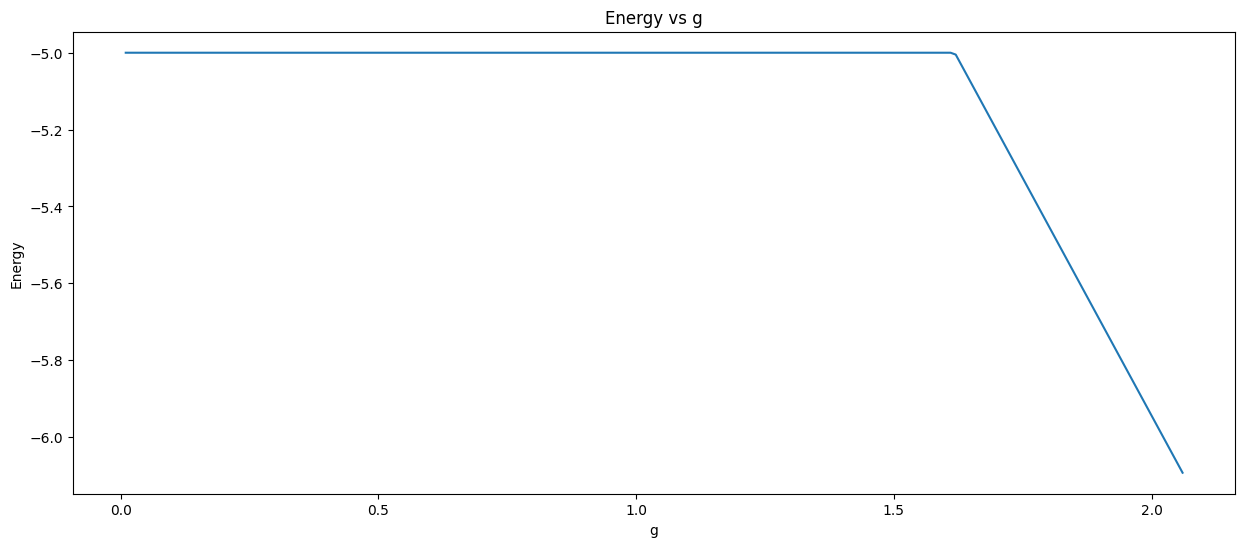

In [74]:
plt.figure(figsize=(15, 6))

plt.plot(g_array[:-3], energy_singles_1[:-3].min(axis=1), label="Energy Unique")
# plt.plot(g_array, energy_singles_1[:], label="Energy Unique")
# plt.plot(g_array, energy_singles_1[:, ], label="Energy Unique")
plt.title(f"Energy vs g")
plt.xlabel("g")
plt.ylabel("Energy")
# plt.legend()
# plt.ylim(-0.25, 0)
plt.show()

## Graphs Occupation and Energies

In [75]:
n = 210

singles_num = 100
multiples_num = 100

g_array = np.zeros((n-1, 1))
occupation_arr_singles = np.zeros((n-1, singles_num))
occupation_arr_multiples = np.zeros((n-1, multiples_num))
energy_singles = np.zeros((n-1, singles_num))
energy_multiples = np.zeros((n-1, multiples_num))

skip = {1.0, 2.0}

In [136]:
# for g_indx in range(1, n):

#     g = g_indx / 100

#     print(g)

#     H, K, V = hamiltonian_dense(site, J_x, J_y, J_z, h_x, h_y, h_z, g)
#     eig_val, eig_vec = np.linalg.eigh(H)

#     indx_singles = index_ones(eig_val, 9)
#     indx_multiples = index_multiples(eig_val, 9)

#     print(indx_singles.shape)

In [ ]:
# shift = 0

# for g_indx in range(1, n):

#     g = g_indx / 100

#     # if g in skip:
#     #     shift += 1
#     #     continue

#     print(g)

#     H, K, V = hamiltonian_dense(site, J_x, J_y, J_z, h_x, h_y, h_z, g)
#     eig_val, eig_vec = np.linalg.eigh(H)

#     indx_singles = index_ones(eig_val, 9)
#     indx_multiples = index_multiples(eig_val, 9)


#     print(indx_singles.shape[0])
#     print(indx_multiples.shape[0])

#     for i_singles in range(indx_singles.shape[0]):
#         D = density_matrix_1(2, site, eig_vec[:, indx_singles[i_singles]], 0)
#         eig_val_D, eig_vec_D = np.linalg.eigh(D)


#         occupation_arr_singles[g_indx-1-shift, i_singles] = np.max(eig_val_D)
#         energy_singles[g_indx-1-shift, i_singles] = eig_val[indx_singles[i_singles]]

#     energy_singles[g_indx-1-shift, :] = energy_singles[g_indx-1-shift, np.argsort(-occupation_arr_singles[g_indx-1-shift, :])]

#     for i_multiples in range(indx_multiples.shape[0]):

#         comb_NO = eig_vec[:, indx_multiples[i_multiples]]

#         res_1 = minimize(
#             constr_ineq,
#             x0=C0,
#             args=(comb_NO,),
#             method='SLSQP',
#             constraints=[
#                 {'type': 'eq', 'fun': constr_eq}
#             ],
#             options={'ftol': 1e-6, 'maxiter': 1000}
#         )["x"]

#         comb_grd_state = comb_NO @ res_1

#         D_comb = density_matrix_1(2, site, comb_grd_state, 0)

#         if np.allclose(np.trace(D_comb), 1) == False:
#              print(D_comb)
#              raise ValueError("Incorect Density matrix.")

#         eig_val_D_comb, eig_vec_D_comb = np.linalg.eigh(D_comb)

#         occupation_arr_multiples[g_indx-1-shift, i_multiples] = np.max(eig_val_D_comb)
#         energy_multiples[g_indx-1-shift, i_multiples] = eig_val[indx_multiples[i_multiples,0]]

#     energy_multiples[g_indx-1-shift, :] = energy_multiples[g_indx-1-shift, np.argsort(-occupation_arr_multiples[g_indx-1-shift, :])]

#     g_array[g_indx-1-shift] = g

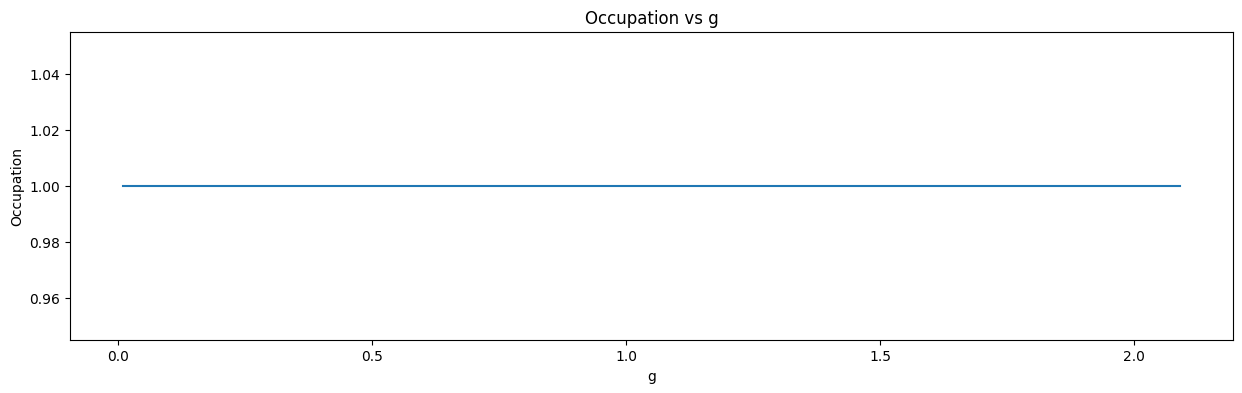

In [ ]:

plt.figure(figsize=(15, 4))

# plt.plot(g_array, occupation_arr.max(axis=1)  , label="Occupation Sym")
plt.plot(g_array, occupation_arr_singles[:, :8].max(axis=1), label="Occupation AntySym")
# plt.plot(g_array, occupation_arr_singles[:, :6], "--", label="Occupation AntySym")
plt.title(f"Occupation vs g")
plt.xlabel("g")
plt.ylabel("Occupation")
# plt.ylim(-0.25, 0)
plt.show()

In [ ]:
occupation_arr_singles[:, :8].sort(axis=1)

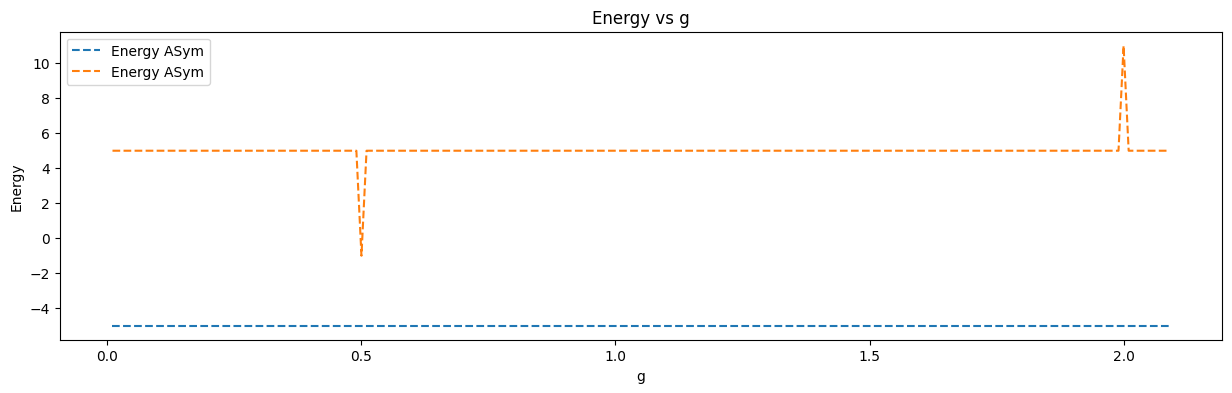

In [ ]:
plt.figure(figsize=(15, 4))

plt.plot(g_array, energy_singles[:, 0], "--", label="Energy ASym")
plt.plot(g_array, energy_singles[:, 1], "--", label="Energy ASym")
# plt.plot(g_array, energy_singles[:, 2], "--", label="Energy ASym")
# plt.plot(g_array, energy_singles[:, 3], "--", label="Energy ASym")
plt.title(f"Energy vs g")
plt.xlabel("g")
plt.ylabel("Energy")
plt.legend()
# plt.ylim(-0.25, 0)
plt.show()

# Produce best ground state for CCC

In [70]:
site = 5
state = 2

J_x = 1
J_y = 0
J_z = 1

h_x = 0
h_y = 0
h_z = -1

g = 0.6

precision = 9

In [71]:
def f_max(C, ground_NO):
    # C is variable; ground_NO is fixed from args
    psi = ground_NO @ C
    D = density_matrix_1(2, site, psi, 0)
    return float(np.real(np.trace(D @ D)))

def constr_ineq(C, ground_NO):
    return 1 - f_max(C, ground_NO)

# optional equality constraint: <psi|psi> = 1
def constr_eq(C):
    return 1 - float(C @ C)

In [72]:
H, K, V = hamiltonian_dense(site, J_x, J_y, J_z, h_x, h_y, h_z, g)
eig_val, eig_vec = np.linalg.eigh(H)

indx_degenerate = index_degenerate(eig_val, precision)

In [88]:
eig_val[np.array(indx_degenerate[2])]

array([-2.70976, -2.70976])

In [89]:
print(len(indx_degenerate))

12


In [92]:
indx_degenerate

[(np.int64(0), np.int64(1)),
 (np.int64(2), np.int64(3)),
 (np.int64(5), np.int64(6)),
 (np.int64(7), np.int64(8)),
 (np.int64(11), np.int64(12)),
 (np.int64(13), np.int64(14)),
 (np.int64(16), np.int64(17)),
 (np.int64(18), np.int64(19)),
 (np.int64(21), np.int64(22)),
 (np.int64(23), np.int64(24)),
 (np.int64(26), np.int64(27)),
 (np.int64(28), np.int64(29))]

In [90]:
occupations = np.zeros(len(indx_degenerate))
occupations_vec = np.zeros((len(indx_degenerate), 2))
dencity_matricies = np.zeros((len(indx_degenerate), 2, 2))

In [96]:
for i in range(len(indx_degenerate)):

    comb_NO =  eig_vec[:, np.array(indx_degenerate[i])]

    C0 = np.zeros((len(indx_degenerate[i])), dtype=complex)
    occ_initial = np.zeros((len(indx_degenerate[i])), dtype=complex)

    for j in range(len(indx_degenerate[i])):

        D_inter = density_matrix_1(2, site, comb_NO[:, j], 0)
        eig_val_D_inter, _ = np.linalg.eigh(D_inter)

        if np.allclose(np.sum(eig_val_D_inter), 1) == False:
            raise ValueError("Incorect Density matrix.")

        occ_initial[j] = np.max(eig_val_D_inter)

    print("Initial:", np.max(occ_initial))

    C0[np.argmax(occ_initial)] = 1

    res_1 = minimize(
        constr_ineq,
        x0=C0,
        args=(comb_NO,),
        method='SLSQP',
        constraints=[
            {'type': 'eq', 'fun': constr_eq}
        ],
        options={'ftol': 1e-6, 'maxiter': 1000}
    )["x"]

    print(constr_eq(res_1) + 1)

    comb_grd_state = comb_NO @ res_1

    print(comb_grd_state.T @ (H @ comb_grd_state))
    print(eig_val[np.array(indx_degenerate[i])])

    D_comb = density_matrix_1(2, site, comb_grd_state, 0)

    if np.allclose(np.trace(D_comb), 1) == False:
            print(D_comb)
            raise ValueError("Incorect Density matrix.")

    eig_val_D_comb, eig_vec_D_comb = np.linalg.eigh(D_comb)

    print(eig_vec_D_comb)

    occupations[i] = np.max(eig_val_D_comb)
    # occupations_vec[i] = eig_vec_D_comb[:, np.argmax(eig_val_D_comb)]
    dencity_matricies[i] = D_comb

Initial: (0.8569400344805979+0j)
0.9999999716879713
(-4.087118682881315+0j)
[-4.08712 -4.08712]
[[-0.-0.j -1.+0.j]
 [-1.-0.j  0.+0.j]]
Initial: (0.9103169446389713+0j)
0.9999997421284399
(-3.6871826715727978+0j)
[-3.68718 -3.68718]
[[ 0.+0.j -1.-0.j]
 [-1.+0.j -0.-0.j]]
Initial: (0.7942352684259376+0j)
0.9999999993960369
(-2.7097644096346265+0j)
[-2.70976 -2.70976]
[[ 0.+0.j -1.-0.j]
 [-1.+0.j -0.-0.j]]
Initial: (0.6467701526064218+0j)
0.9999998878756857
(-2.612156876649018+0j)
[-2.61216 -2.61216]
[[-0.-0.j -1.+0.j]
 [-1.-0.j  0.+0.j]]
Initial: (0.7406664204773398+0j)
0.9999999929651662
(-1.3607634534366064+0j)
[-1.36076 -1.36076]
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
Initial: (0.8000575954750824+0j)
0.9999997222983814
(-0.5433342254868676+0j)
[-0.54333 -0.54333]
[[ 0.+0.j -1.-0.j]
 [-1.+0.j -0.-0.j]]
Initial: (0.6354272299103509+0j)
0.9999999912552049
(-0.32539498925753774+0j)
[-0.32539 -0.32539]
[[-1.-0.j -0.+0.j]
 [-0.-0.j  1.+0.j]]
Initial: (0.6868955494920322+0j)
0.9999999996855413
(

/Users/gilfrim/Desktop/Projects/Computational_Analysis_of_Many_Rotor_Systems/.venv/lib/python3.12/site-packages/scipy/_lib/array_api_compat/numpy/_aliases.py:106: ComplexWarning: Casting complex values to real discards the imaginary part
  return x.astype(dtype=dtype, copy=copy)
/var/folders/vt/f4sbj2d11gbbb9q5816khz2m0000gn/T/ipykernel_5737/2023134865.py:52: ComplexWarning: Casting complex values to real discards the imaginary part
  dencity_matricies[i] = D_comb


In [76]:
D = dencity_matricies[np.argmax(occupations)]
_, eig_vec_D = np.linalg.eigh(D)

In [77]:
eig_vec_D

array([[-1.,  0.],
       [ 0.,  1.]])

In [78]:
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)

sigma_x_i = eig_vec_D.T.conj() @ sigma_x @ eig_vec_D
sigma_y_i = eig_vec_D.T.conj() @ sigma_x @ eig_vec_D
sigma_z_i = eig_vec_D.T.conj() @ sigma_x @ eig_vec_D

In [79]:
sigma_x

array([[0.+0.j, 1.+0.j],
       [1.+0.j, 0.+0.j]])

In [80]:
sigma_x_i

array([[-0.+0.j, -1.+0.j],
       [-1.+0.j,  0.+0.j]])

In [81]:
H_new, K_new, V_new = hamiltonian_dense(site, J_x, J_y, J_z, h_x, h_y, h_z, g, Import=True, sigma_x_i=sigma_x_i, sigma_y_i=sigma_y_i, sigma_z_i=sigma_z_i)

In [82]:
val, vec = np.linalg.eigh(H_new)

In [83]:
vec[:, 0]

array([ 0.     +0.j, -0.35811+0.j,  0.30837+0.j,  0.04974+0.j, -0.19607+0.j,  0.06256+0.j, -0.1123 +0.j,  0.24581+0.j,  0.07309+0.j,  0.06043+0.j, -0.01069+0.j, -0.12283+0.j,  0.12298+0.j,  0.23512+0.j, -0.18538+0.j, -0.17272+0.j,  0.17272+0.j,  0.18538+0.j, -0.23512+0.j, -0.12298+0.j,  0.12283+0.j,  0.01069+0.j, -0.06043+0.j, -0.07309+0.j, -0.24581+0.j,  0.1123 +0.j, -0.06256+0.j,  0.19607+0.j, -0.04974+0.j, -0.30837+0.j,  0.35811+0.j,  0.     +0.j])

In [84]:
t_periodic(site, 2, g, False, Import_K_V=True, K_import=K_new, V_import=V_new.reshape(2, 2, 2, 2))

ValueError: Diverges.